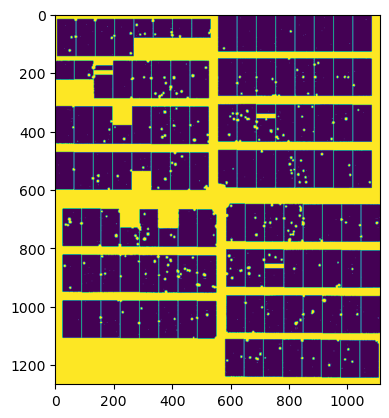

In [19]:
from extra_data import open_run
import extra_data
#from extra_data.components import AGIPD1M
from extra_geom import AGIPD_1MGeometry
import numpy as np
import h5py
import matplotlib.pyplot as plt



geom_fn = "./agipd_p008039_r0014_v16.geom"
ref_geom = AGIPD_1MGeometry.from_crystfel_geom(geom_fn)


with h5py.File("./mask_hvoff_20250311.h5",'r') as f:
    mask = f['/entry_1/data_1/mask'][...]

out = np.ones((1266, 1112))

ref_geom.position_modules(mask, out=out)

out*=2


plt.figure()
plt.imshow(out)

with h5py.File("./mask_flat.h5", 'w') as f:
    f['/mask'] = out.flatten()

with h5py.File("./mask_sq.h5", 'w') as f:
    f['/mask'] = out
    
with h5py.File("./mask_cube.h5", 'w') as f:
    f['/mask'] = mask

with h5py.File("./mask_sm.h5", 'w') as f:
    f['/mask'] = mask[3]

In [17]:
np.unique(out)

array([0., 2.])

In [18]:
import shutil
import h5py

# 1. Copy and rename the file
shutil.copy('../recon_0001/data/square_make_det.h5', '../recon_0001/data/square_make_det_edit.h5')

# 2. Open the new file and change the dataset
with h5py.File('../recon_0001/data/square_make_det_edit.h5', 'a') as f:
    if "mask" in f:
        # Overwrite using the slicing method (if shape is same)
        # or del f["my_dataset"] then f.create_dataset(...)
        f["mask"][...] = out.flatten()

In [3]:
import re

def offset_geometry_by_module(input_path, output_path):
    # Regex to find: p(number)a(number)/min_ss = (value)
    # Group 1: The module number
    # Group 2: The parameter name (min_ss or max_ss)
    # Group 3: The original value
    pattern = re.compile(r'p(\d+)a\d+/(min_ss|max_ss)\s*=\s*(\d+)')

    new_lines = []

    with open(input_path, 'r') as f:
        for line in f:
            match = pattern.search(line)
            if match:
                module_num = int(match.group(1))
                param_name = match.group(2)
                original_value = int(match.group(3))
                
                # Calculate the new value: original + (512 * p)
                new_value = original_value + (512 * module_num)
                
                # Reconstruct the line (keeping the prefix)
                # We use the match start/end to preserve the line's structure
                prefix = line.split('=')[0].split('/')[0] # e.g., p0a0
                new_line = f"{prefix}/{param_name} = {new_value}\n"
                new_lines.append(new_line)
            else:
                # Keep everything else as is
                new_lines.append(line)

    with open(output_path, 'w') as f:
        f.writelines(new_lines)

    print("Success! Geometry file updated using p*512 offset.")

offset_geometry_by_module('./agipd_p008039_r0014_v16.geom', './agipd_linear.geom')

Success! Geometry file updated using p*512 offset.


Text(0.5, 1.0, 'qz')

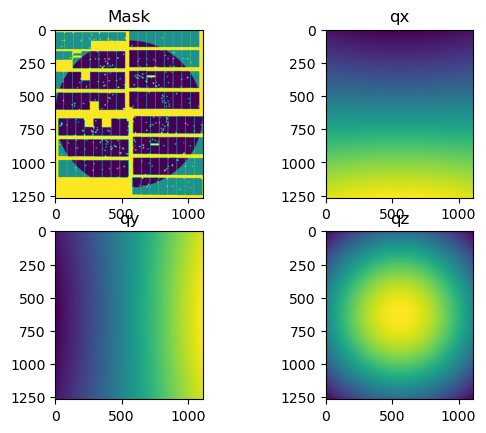

In [29]:
with h5py.File('../spi_0001/data/det_sim_masked.h5', 'r') as f:
    m = f['/mask'][...]
    qx = f['/qx'][...]
    qy = f['/qy'][...]
    qz = f['/qz'][...]


fig, axes = plt.subplots(2,2)

axes[0,0].imshow(m.reshape(1266, 1112))
axes[0,0].set_title('Mask')
axes[0,1].imshow(qx.reshape(1266, 1112))
axes[0,1].set_title('qx')
axes[1,0].imshow(qy.reshape(1266, 1112))
axes[1,0].set_title('qy')
axes[1,1].imshow(qz.reshape(1266, 1112))
axes[1,1].set_title('qz')

